## Visualization

In [95]:
!python mac_camera.py

Current working directory: /Users/bastienmarconato/Library/CloudStorage/OneDrive-epfl.ch/MA1/Basics of mobile robotics/Projet-Mobile-Robotics/Global_Navigation
connected to the Thymio
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6
OBSTACLES DETECTED: 6

---------------------------------
I found the robot, the obstacles and the goal!

POSITION OF THE ROBOT: (281, 479)


POSITION OF THE

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import json

speed_to_mms = 0.42

# Read data
with open('measurements/debug.json', 'r') as file:
    data = json.load(file)
    name = data['name']
    data = data['data']
    print(f"name: {name}, {len(data)} samples")

# Put data in numpy arrays for convenience
time_samples = np.array([sample["time"] for sample in data])
time_samples = time_samples - time_samples[0]
P = np.array([sample["P"] for sample in data])
x_hat = np.array([sample["x_hat"] for sample in data])
target_speed = np.array([sample["target_speed"] for sample in data])*speed_to_mms
encoder = np.array([sample["encoder"] for sample in data])
z_cam = np.array([sample["camera"] for sample in data])
prox_horizontal = np.array([sample["prox_horizontal"] for sample in data])
print(encoder[:10,0])
print(f"average loop time: {np.mean(np.gradient(time_samples))*1000} ms")


name: Thymio 548, 214 samples
[ 0.   -1.26 -1.68  0.   -0.21  1.89 13.02 15.75 15.54 15.75]
average loop time: 192.19205646871407 ms


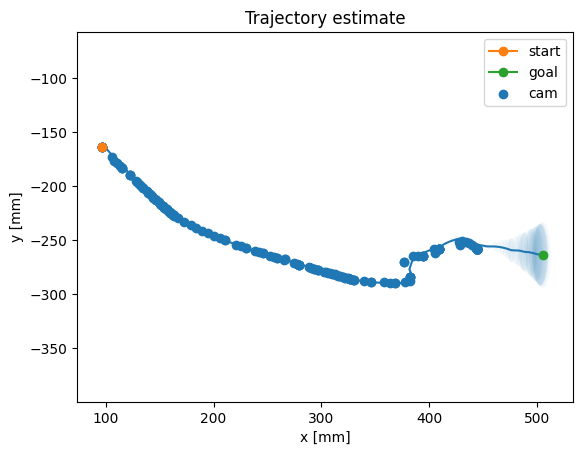

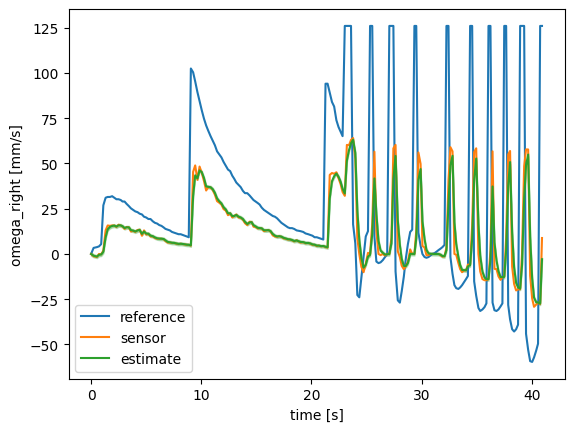

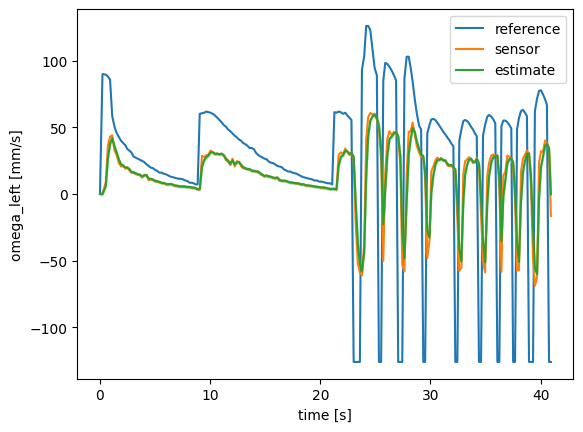

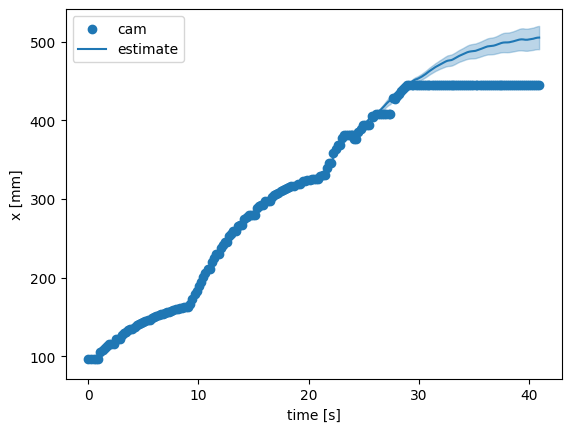

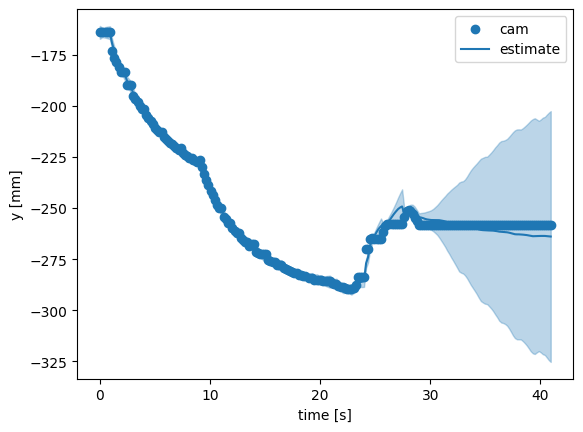

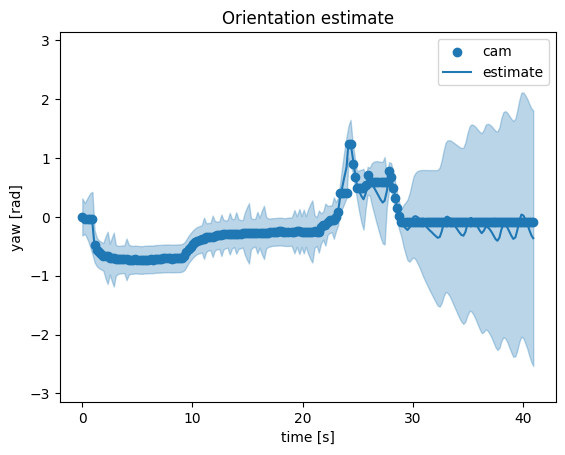

In [97]:
%matplotlib inline

# Plot trajectory estimate
plt.plot(x_hat[:,0], x_hat[:,1])
plt.plot(x_hat[0,0], x_hat[0,1], marker='o', label='start')
plt.plot(x_hat[-1,0], x_hat[-1,1], marker='o', label='goal')
plt.scatter(z_cam[:,0], z_cam[:,1], marker='o', label='cam')
#plt.quiver(goal[0],goal[1],20, 20, angles=[goal[2]])
std_x = np.sqrt(P[:,0,0])
std_y = np.sqrt(P[:,1,1])

## draw ellipses to illustrate estimate variance
for k in np.linspace(0,x_hat.shape[0]-1, 100, dtype=int):   # skip some samples
    plt.gca().add_patch(Ellipse(
        xy=(x_hat[k,0], x_hat[k,1]),
        width=std_x[k],
        height=std_y[k],
        alpha=0.05
    ))
    #plt.scatter(x_hat[k,0], x_hat[k, 1], marker='x', alpha=0.5)

plt.title("Trajectory estimate")
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.legend()
plt.axis('equal')
plt.show()


# Plot state estimate
## Right wheel speed
z_omega_r = encoder[:,0]
omega_r_hat = x_hat[:,3]
std_omega_r = np.sqrt(P[:, 3, 3])

plt.plot(time_samples, target_speed[:,0], label='reference')
plt.plot(time_samples, z_omega_r, label='sensor')
plt.plot(time_samples, omega_r_hat, label='estimate')
plt.fill_between(time_samples,
                 omega_r_hat-std_omega_r,
                 omega_r_hat+std_omega_r,
                 color='C2',
                 alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("omega_right [mm/s]")
plt.legend()
plt.show()

## Left wheel speed
z_omega_l = encoder[:,1]
omega_l_hat = x_hat[:,4]
std_omega_l = np.sqrt(P[:, 4, 4])

plt.plot(time_samples, target_speed[:,1], label='reference')
plt.plot(time_samples, z_omega_l, label='sensor')
plt.plot(time_samples, omega_l_hat, label='estimate')
plt.fill_between(time_samples,
                 omega_l_hat-std_omega_l,
                 omega_l_hat+std_omega_l,
                 color='C2',
                 alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("omega_left [mm/s]")
plt.legend()
plt.show()


## Position x
plt.scatter(time_samples, z_cam[:,0], marker='o', label='cam')
plt.plot(time_samples, x_hat[:,0], label='estimate')
plt.fill_between(time_samples,
                 x_hat[:,0]-std_x,
                 x_hat[:,0]+std_x,
                 color='C0',
                 alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("x [mm]")
plt.legend()
plt.show()


## Position y
plt.scatter(time_samples, z_cam[:,1], marker='o', label='cam')
plt.plot(time_samples, x_hat[:,1], label='estimate')
plt.fill_between(time_samples,
                 x_hat[:,1]-std_y,
                 x_hat[:,1]+std_y,
                 color='C0',
                 alpha=0.3)
plt.xlabel("time [s]")
plt.ylabel("y [mm]")
plt.legend()
plt.show()


## Position theta
std_theta = np.sqrt(P[:, 2, 2])
plt.scatter(time_samples, z_cam[:,2], marker='o', label='cam')
plt.plot(time_samples, x_hat[:,2], label='estimate')
plt.fill_between(time_samples,
                 x_hat[:,2]-std_theta,
                 x_hat[:,2]+std_theta,
                 color='C0',
                 alpha=0.3)
plt.title("Orientation estimate")
plt.ylim(-np.pi, np.pi)
plt.xlabel("time [s]")
plt.ylabel("yaw [rad]")
plt.legend()
plt.show()
